# Imports

- Evaluate the effect of timing of P-fertilizer

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
plt.style.use('ggplot')
import pickle

import geopandas as gpd

In [2]:
from CAgsalML.causal import  dml_sensitivity_analysis
from CAgsalML.tuning import GPOptimizer
from CAgsalML.transformers import SpatialTransform

INFO (2025-12-05 16:08:53,233) [__init__/<module> (line 54)]: Using balance version 0.12.0


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import  r2_score
from sklearn.model_selection import train_test_split, cross_val_predict
from skopt.space import Categorical, Integer, Real

In [4]:
RANDOM_SEED = 43

# Adjust data

In [5]:
data = pd.read_pickle('../data-definitive/data-dag.pkl')
adjustment_nodes = [
    'fertilizerTiming', 'otherManagement', 'neighborsAdvice',
    'investmentCap', 'accessibilityRAI', 'fieldHistory',
    'crop', 'variety', 'previousAdvice', 'phenology',
    'soil', 'weather', 'elevation'
]
columns_dict = { # Includes all nodes, not only adjustment nodes
    'fieldHistory': [
        'fieldsize_value',  'history_maize', 'history_nocrop', 'history_legume',
        'history_rootandtuber', 'history_oilseed'
    ],
    'fertilizerAmount': ['fertN_total', 'fertP_total'],
    'accessibilityRAI': ['accessibility_rai'],
    'elevation': ['elevation_value'],
    'previousAdvice': ['treat_previousadvice'],
    'investmentCap': ['investing_capacity_index'],
    'weather': [
        '0to10perc_season_tmean', '0to10perc_season_srad',
        '0to10perc_season_prec', '0to10perc_season_rainydays',
        '10to20perc_season_tmean', '10to20perc_season_srad',
        '10to20perc_season_prec', '10to20perc_season_rainydays',
        '20to30perc_season_tmean', '20to30perc_season_srad',
        '20to30perc_season_prec', '20to30perc_season_rainydays',
        '30to40perc_season_tmean', '30to40perc_season_srad',
        '30to40perc_season_prec', '30to40perc_season_rainydays',
        '40to50perc_season_tmean', '40to50perc_season_srad',
        '40to50perc_season_prec', '40to50perc_season_rainydays',
        '50to60perc_season_tmean', '50to60perc_season_srad',
        '50to60perc_season_prec', '50to60perc_season_rainydays',
        '60to70perc_season_tmean', '60to70perc_season_srad',
        '60to70perc_season_prec', '60to70perc_season_rainydays',
        '70to80perc_season_tmean', '70to80perc_season_srad',
        '70to80perc_season_prec', '70to80perc_season_rainydays',
        '80to90perc_season_tmean', '80to90perc_season_srad',
        '80to90perc_season_prec', '80to90perc_season_rainydays',
        '90to100perc_season_tmean', '90to100perc_season_srad',
        '90to100perc_season_prec', '90to100perc_season_rainydays',
        '0to100perc_season_tmean', '0to100perc_season_srad',
        '0to100perc_season_prec', '0to100perc_season_rainydays',
    ],
    'soil': [
        'soilfert_cec', 'soilfert_oc', 'soilpp_clay',
        'soilpp_density', 'soilpp_sand', 'soil_sandy'
    ],
    'outcome': ['outcome_prodstd'],
    'fertilizerTiming': [
        'fertN_56leaves', 'fertN_810leaves', 'fertN_basal', 'fertN_emergence',
        'fertN_kneehigh','fertN_tasselingsilking', 'fertP_56leaves',
        'fertP_810leaves', 'fertP_basal', 'fertP_emergence', 'fertP_kneehigh',
        'fertP_tasselingsilking'
    ],
    'otherManagement': [
       'herbicide_post', 'herbicide_pre', 'herbicide_any', 'manure_any',
       'planting_handhoe', 'planting_ploughsowing', 'planting_string',
       'residue_burn', 'residue_feedtoanimals', 'residue_incorporateinthesoil',
       'residue_leaveonfield', 'residue_onfield'
    ],
    'neighborsAdvice': ['neighbor_previousadvice_avg'],
    'variety': ['variety_hybrid', 'variety_recycled'],
    'phenology': ['phenology_losstd'],
    'crop': ['crop_maize'],
}
outcome_name = 'outcome_prodstd'
treatment_name = 'fertP_total'
data['fertN_total'] /= 100 # Scale fertilizer amounts to 100 kg 
data['fertP_total'] /= 100 
# Bad controls
bad_controls = [i for c in (set(columns_dict) - set(adjustment_nodes)) for i in columns_dict[c]]
features = [i for v in columns_dict.values() for i in v]
features = list(set(features) - set(bad_controls) - {outcome_name, treatment_name})
features.append('fertN_total')  # Include fertP_amount as a covariate

# Import geometries to assign spatial groups for CV
crs = 'EPSG:32736'

points = gpd.read_file('../data-definitive/geo/points.geojson')
points = points.set_index('fieldID')[['geometry']]
points = points.loc[data.index]
points = points.to_crs(crs)

admin = gpd.read_file('../data-definitive/geo/tza_shp/tza_admbnda_adm3_20181019.shp')
admin = admin.to_crs(crs)

# Perform a spatial join to assign ADM3_PCODE and ADM2_PCODE to each point
points = gpd.sjoin(points, admin[['ADM3_PCODE', 'ADM2_PCODE', 'geometry']], how="left", predicate="within")
points['ADM2_PCODE'] = points['ADM2_PCODE'].replace({'TZ2610': 'TZ2609'})
# Drop the 'index_right' column which is a byproduct of the sjoin
points = points.drop(columns=['index_right'])

# This is the data before transforming it for DAG, just in case
clean_data = pd.read_pickle('../data-definitive/maize-soya-clean.pkl')

# Get subset
index_zone_subset = points.geometry.x.where(lambda x: x < 6e5).dropna().index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

# Add lan, lon as features
data['lat'] = (points.geometry.y - points.geometry.y.mean())/points.geometry.y.std()
data['lon'] = ((points.geometry.x - points.geometry.x.mean())/points.geometry.x.std())
features.extend(['lat', 'lon'])

In [6]:
TIMINGS = [
    'basal', 'emergence', 'kneehigh', '56leaves', '810leaves',
    'tasselingsilking'
]
# Check the variability of amounts. If amounts are not highly variable
# then considering binary treatment would not be 
data[[f'fertP_{t}' for t in TIMINGS]].replace({0: np.nan}).describe()

,fertP_basal,fertP_emergence,fertP_kneehigh,fertP_56leaves,fertP_810leaves,fertP_tasselingsilking
count,758.000000,40.000000,5.000000,87.000000,24.000000,4.000000
mean,0.898033,0.504167,0.486024,0.491903,0.411263,0.507143
std,0.202688,0.046032,0.105818,0.055111,0.150313,0.070470
min,0.333333,0.333333,0.333333,0.250000,0.019608,0.428571
25%,1.000000,0.500000,0.454545,0.500000,0.312500,0.482143
50%,1.000000,0.500000,0.500000,0.500000,0.500000,0.500000
75%,1.000000,0.500000,0.517241,0.500000,0.500000,0.525000
max,1.000000,0.666667,0.625000,0.666667,0.600000,0.600000


In [7]:
# data[treatment_name] = data[treatment_name] > 0
T_series = data[treatment_name]
Y_series = data[outcome_name]

transformed_data = pd.DataFrame(index=data.index)
# Normalize features
numeric_features = list(data[features].select_dtypes(include='number').columns)
dummy_features = list((data.loc[:, data.isin([0, 1]).all()].columns))
timing_features = [f'fertP_{t}' for t in TIMINGS[:]]

numeric_features = list((set(numeric_features) - set(dummy_features)) - set(timing_features))

transformed_data[numeric_features] = StandardScaler().fit_transform(
    data[numeric_features]
).astype(np.float32)
transformed_data[dummy_features] = data[dummy_features].astype(float)
transformed_data[timing_features] = data[timing_features]

# Transform the outcome crop-wise
tmp_series = data.loc[data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = (tmp_series - tmp_series.mean())/tmp_series.std()
tmp_series = data.loc[~data.crop_maize, 'outcome_prodkgha']
transformed_data['outcome_prodstd'] = transformed_data.outcome_prodstd.fillna(
    (tmp_series - tmp_series.mean())/tmp_series.std()
)
# Drop those rows with no production
transformed_data = transformed_data.loc[transformed_data.outcome_prodstd.notna()]
# Drop rows with values not within feasible range
NORMALIZED_LIM = 5
transformed_data = transformed_data.loc[
    (transformed_data < NORMALIZED_LIM).all(axis=1) & 
    (transformed_data > -NORMALIZED_LIM).all(axis=1)
]
# Redefine index of samples
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [8]:
# Spatially demean the outcome
spatial_transformer = SpatialTransform(
    points.geometry, maxlag=50e3, esitmator='cressie',
    model='matern', n_lags=50, use_nugget=True
)
spatial_transformer.fit(transformed_data.outcome_prodstd)
transformed_data['outcome_prodstd'] = spatial_transformer.transform_demean()

In [9]:
# Add treatment and Keep only complete records
transformed_data[treatment_name] = data[treatment_name]
transformed_data = transformed_data.dropna()
index_zone_subset = transformed_data.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]

In [10]:
# Generate timing clusters
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X_trans = np.sqrt(transformed_data[timing_features].values)

dbscan = DBSCAN(eps=np.sqrt(.01), min_samples=20) 
appl_clusters_df = pd.DataFrame(transformed_data[timing_features], columns=timing_features)
appl_clusters_df['cluster'] = dbscan.fit_predict(X_trans)
appl_clusters_df['Cluster name'] = appl_clusters_df['cluster'].map({
    -1: '0Noise',
    0: '100Basal',
    1: '50Basal-50Emergence',
    2: '50Basal-50V56',
})
# appl_clusters_df['Cluster name'] = appl_clusters_df['cluster']
(appl_clusters_df.groupby('Cluster name').agg(('mean' , 'std'))*100).astype(int)

fertP_basal     fertP_emergence     fertP_kneehigh      \
                           mean std            mean std           mean std   
Cluster name                                                                 
0Noise                       53  15               0   5              5  16   
100Basal                    100   0               0   0              0   0   
50Basal-50Emergence          50   0              50   0              0   0   
50Basal-50V56                50   0               0   0              0   0   

                    fertP_56leaves     fertP_810leaves      \
                              mean std            mean std   
Cluster name                                                 
0Noise                           9  20              29  22   
100Basal                         0   0               0   0   
50Basal-50Emergence              0   0               0   0   
50Basal-50V56                   49   0               0   0   

                    fertP_tasselingsilking     cluster      
                                      mean std    mean std  
Cluster name                                                
0Noise                                   1   7    -100   0  
100Basal                                 0   0       0   0  
50Basal-50Emergence                      0   0     100   0  
50Basal-50V56                            0   0     200   0

In [11]:
appl_clusters_df['Cluster name'].value_counts()

Cluster name
100Basal               565
50Basal-50V56           74
0Noise                  34
50Basal-50Emergence     33
Name: count, dtype: int64

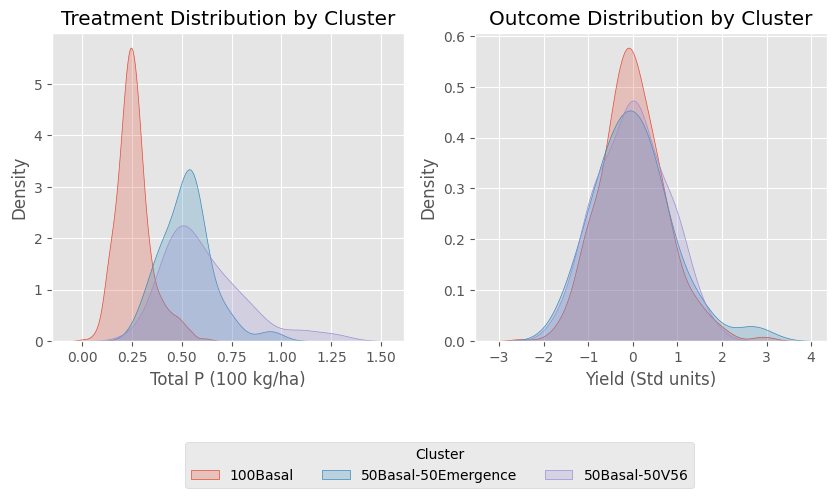

In [12]:
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=transformed_data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('Total P (100 kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=transformed_data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            outcome_name
        ],
        fill=True, ax=ax,
        label=f'{c}'
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (Std units)')

ax.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.5, 0., .0), ncol=3, title='Cluster')

Weights calculated. Range: 0.21 - 10.52


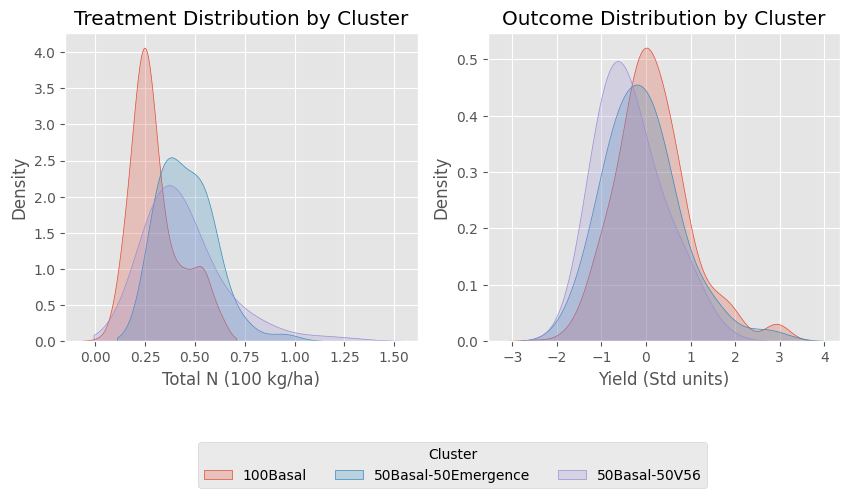

In [13]:
appl_clusters_df[treatment_name] = transformed_data[treatment_name]

def compute_balancing_weights(df, group_col, treatment_col, n_bins=10, clip_max=10.0):
    """
    Calculates sample weights to ensure every group in 'group_col'
    has the same distribution of 'treatment_col' as the global population.
    """
    df['t_bin'] = pd.qcut(df[treatment_col], q=n_bins, labels=False, duplicates='drop')
    
    global_probs = df['t_bin'].value_counts(normalize=True).sort_index()
    group_probs = df.groupby(group_col)['t_bin'].value_counts(normalize=True).unstack(fill_value=0.0001) 
    # Create a mapping dictionary for fast lookup
    weights_map = {}
    
    for group in group_probs.index:
        weights_map[group] = {}
        for bin_id in global_probs.index:
            target_p = global_probs[bin_id]
            actual_p = group_probs.loc[group, bin_id]
            
            # Calculate weight
            weight = target_p / actual_p
            weights_map[group][bin_id] = weight

    def get_weight(row):
        return weights_map[row[group_col]].get(row['t_bin'], 1.0)

    df['sample_weight'] = df.apply(get_weight, axis=1)
    df['sample_weight'] = df['sample_weight'].clip(upper=clip_max)
    df['sample_weight'] = df['sample_weight'] * (len(df) / df['sample_weight'].sum())
    print(f"Weights calculated. Range: {df['sample_weight'].min():.2f} - {df['sample_weight'].max():.2f}")
    
    return df['sample_weight']

sample_weights = compute_balancing_weights(appl_clusters_df, 'Cluster name', treatment_name, n_bins=10, clip_max=10.0)
# Check the common support on treatment and outcome for the different clusters
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for c in np.unique(appl_clusters_df['Cluster name'].unique()):
    if c == '0Noise':
        continue
    ax = axes[0]
    sns.kdeplot(
        x=transformed_data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            treatment_name
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Treatment Distribution by Cluster')
    ax.set_xlabel('Total N (100 kg/ha)')

    ax = axes[1]
    sns.kdeplot(
        x=transformed_data.loc[
            appl_clusters_df.loc[appl_clusters_df['Cluster name'] == c].index,
            outcome_name
        ],
        fill=True, ax=ax,
        label=f'{c}',
        weights=sample_weights
    )
    ax.set_title('Outcome Distribution by Cluster')
    ax.set_xlabel('Yield (Std units)')

ax.legend(loc='lower center', bbox_to_anchor=(-0.1, -0.5, 0., .0), ncol=3, title='Cluster')

In [14]:
# data_backup = transformed_data.copy()
# transformed_data = data_backup.copy()

In [15]:
# Add the timing dummies to the data. Note that the noise dummy is not added
timing_dummies = pd.get_dummies(appl_clusters_df['Cluster name'], prefix='timing', drop_first=True).astype(int)
transformed_data = pd.concat([transformed_data, timing_dummies], axis=1)
features.extend(timing_dummies.columns)

In [16]:
transformed_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
40to50perc_season_prec,706.0,0.008363,0.923885,-1.504037,-0.681161,-0.133903,0.482873,4.154753
30to40perc_season_prec,706.0,0.030409,0.918916,-2.737831,-0.646659,0.032932,0.653601,2.941907
fertN_56leaves,706.0,0.026104,1.002931,-0.921755,-0.921755,-0.173944,0.837193,2.509423
10to20perc_season_prec,706.0,0.089382,1.022764,-3.163620,-0.519162,0.087296,0.889208,2.333439
20to30perc_season_rainydays,706.0,0.142742,0.852637,-4.857158,-0.224339,0.764690,0.764690,0.764690
...,...,...,...,...,...,...,...,...
outcome_prodstd,706.0,-0.014300,0.757770,-2.546480,-0.483412,-0.036289,0.418317,3.107438
fertP_total,706.0,0.319579,0.167443,0.004567,0.220690,0.269365,0.381332,1.274569
timing_100Basal,706.0,0.800283,0.400071,0.000000,1.000000,1.000000,1.000000,1.000000
timing_50Basal-50Emergence,706.0,0.046742,0.211236,0.000000,0.000000,0.000000,0.000000,1.000000


# Effect estimation pipeline

## Generalized propensity score

In [17]:
# x_names = timing_features
x_names = list(timing_dummies.columns)
w_names = list(set(features) - set(x_names))

training_idxs, testing_idxs = train_test_split(index_zone_subset, random_state=RANDOM_SEED)
print(f"{len(training_idxs)} training samples")
print(f"{len(testing_idxs)} testing samples")
print(f'N features: {len(x_names)+len(w_names)}')

529 training samples
177 testing samples
N features: 95


In [18]:
# First we need a model for the treatment
X_train = transformed_data.loc[training_idxs, w_names + x_names]
t_train = transformed_data.loc[training_idxs, treatment_name]

optimizer_treatment = GPOptimizer(
    model=GradientBoostingRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=6),
        # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
        n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
        random_state=RANDOM_SEED
    )
)
model_treatment, cv_scores_treatment = optimizer_treatment.cv_optimize(
    X_train, t_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=50, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [19]:
model_treatment = model_treatment.fit(X_train, t_train)
test_score = r2_score(
    y_true=transformed_data.loc[testing_idxs, treatment_name],
    y_pred=model_treatment.predict(transformed_data.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_treatment):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(t_train, model_treatment.predict(X_train)):.3f}')

CV R2 mean: 0.806
Test R2: 0.732
Train R2: 0.923


In [20]:
pd.Series(
    model_treatment.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

60to70perc_season_rainydays    0.201612
timing_50Basal-50V56           0.159716
timing_100Basal                0.129067
variety_recycled               0.093819
fertN_basal                    0.052922
planting_ploughsowing          0.044859
investing_capacity_index       0.024862
neighbor_previousadvice_avg    0.023005
0to10perc_season_tmean         0.021582
history_legume                 0.018978
dtype: float64

<Axes: ylabel='Count'>

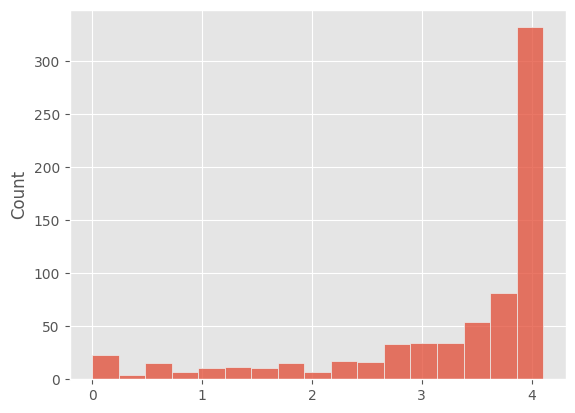

In [21]:
# Use Zhu et al. (2018) and Hirano and Gimbens (2004) approach to estimate PS for continuous treatments
from scipy import stats
T = transformed_data.loc[:, treatment_name].values
# Get the CV predictions to estimate the variance of residuals
T_pred = cross_val_predict(
    model_treatment, 
    X=transformed_data.loc[:, w_names + x_names],
    y=transformed_data.loc[:, treatment_name]
)
T_res = T - T_pred
res_var = np.var(T_res)

# Estimate the GPS
# gps = (1/(np.sqrt(2*np.pi*res_var)))*np.exp((-1/(2*res_var))*treatment_res**2)
gps_density = stats.norm.pdf(
    T, 
    loc=T_pred, 
    scale=res_var**.5 # Scale is sd in this function
)
sns.histplot(gps_density)

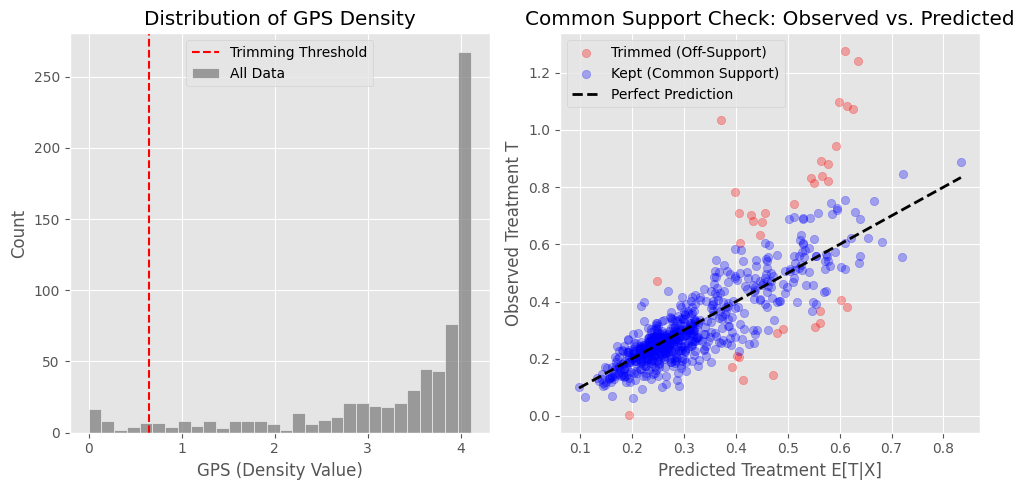

In [22]:
threshold = np.quantile(gps_density, 0.05)
mask_support = gps_density >= threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
ax = axes[0]

sns.histplot(gps_density, bins=30, ax=axes[0], color='grey', label='All Data')
ax.axvline(threshold, color='red', linestyle='--', label='Trimming Threshold')
ax.set_title("Distribution of GPS Density")
ax.set_xlabel("GPS (Density Value)")
ax.legend()


ax = axes[1]
ax.scatter(T_pred[~mask_support], T[~mask_support], alpha=0.3, color='red', label='Trimmed (Off-Support)')
ax.scatter(T_pred[mask_support], T[mask_support], alpha=0.3, color='blue', label='Kept (Common Support)')
ax.plot([min(T_pred), max(T_pred)], [min(T_pred), max(T_pred)], 'k--', lw=2, label='Perfect Prediction')

ax.set_title("Common Support Check: Observed vs. Predicted")
ax.set_xlabel("Predicted Treatment E[T|X]")
ax.set_ylabel("Observed Treatment T")
ax.legend()

plt.tight_layout()
plt.show()

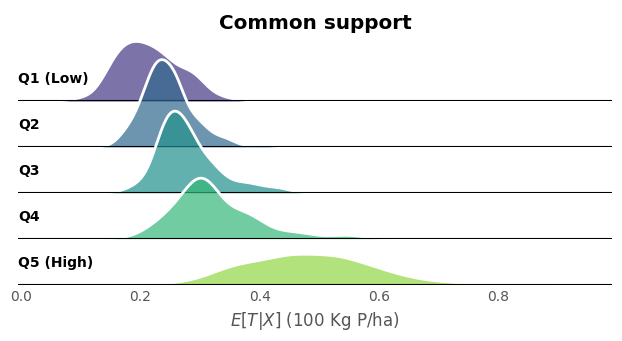

In [23]:
tmp_df = pd.DataFrame({'T_pred': T_pred[mask_support], 'Strata': pd.qcut(T[mask_support], 5, labels=False)})

g = sns.FacetGrid(tmp_df, row="Strata", hue="Strata", aspect=9, height=.75, palette="viridis")
g.map(sns.kdeplot, "T_pred", clip_on=False, fill=True, alpha=0.7, lw=0)
g.map(sns.kdeplot, "T_pred", clip_on=False, color="w", lw=2)

g.fig.subplots_adjust(hspace=-.5)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
g.axes.flat[0].set_title("Common support", fontweight='bold', y=.7) 
g.axes.flat[-1].set_xlabel(r'$E[T|X]$'+' (100 Kg P/ha)')

# Optional: Add text labels for each stratum
for ax, label in zip(g.axes.flat, ["Q1 (Low)", "Q2", "Q3", "Q4", "Q5 (High)"]):
    ax.text(0, 0.2, label, fontweight="bold", transform=ax.transAxes)
    ax.axhline(0, color='k', linestyle="-")
    ax.set_facecolor('none')
    ax.grid(None)
    ax.tick_params(length=0)

<Axes: ylabel='Density'>

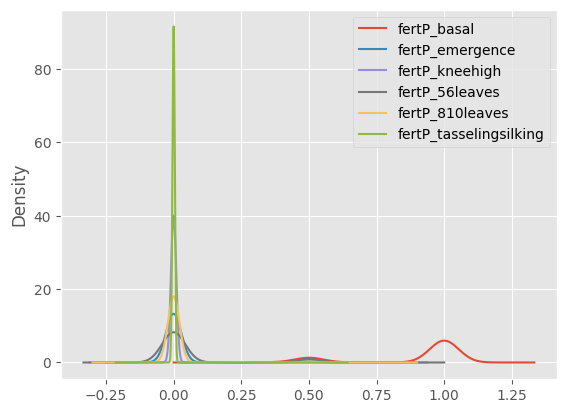

In [24]:
# Check the distribution of timing to select only those that have a good distribution
transformed_data.loc[:, timing_features].plot.kde()

In [25]:
# Trim extreme residuals
transformed_data_pstrimmed = transformed_data.copy()
transformed_data_pstrimmed = transformed_data_pstrimmed.loc[gps_density > threshold]

In [26]:
transformed_data_pstrimmed = transformed_data.copy()
index_zone_subset = transformed_data_pstrimmed.index
points = points.loc[index_zone_subset]
data = data.loc[index_zone_subset]
clean_data = clean_data.loc[index_zone_subset]
transformed_data_pstrimmed.shape

(706, 97)

## Outcome model $q(X, W)$

In [27]:
y_train = transformed_data_pstrimmed.loc[training_idxs, outcome_name]

# optimizer_q = GPOptimizer(
#     model=RandomForestRegressor,
#     model_kwargs=dict(
#         max_depth=Integer(name='max_depth', low=2, high=10),
#         max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
#         min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
#         n_estimators=100, random_state=RANDOM_SEED
#     )
# )

optimizer_q = GPOptimizer(
    model=GradientBoostingRegressor,
    model_kwargs=dict(
        max_depth=Integer(name='max_depth', low=2, high=6),
        # max_features=Categorical(name='max_features', categories=['sqrt', 'log2']),
        # min_samples_leaf=Integer(name='min_samples_leaf', low=1, high=50),
        learning_rate=Real(name='learning_rate', low=1e-3, high=1), 
        n_estimators=1000, n_iter_no_change=20, max_features='sqrt',
        random_state=RANDOM_SEED
    )
)
model_q, cv_scores_q = optimizer_q.cv_optimize(
    X_train, y_train,
    cv=5,
    cv_kwargs=dict(n_jobs=-1, scoring='r2'),
    gp_kwargs=dict(n_calls=100, n_initial_points=5, verbose=False, random_state=RANDOM_SEED)
)

In [28]:
model_q = model_q.fit(X_train, y_train)
test_score = r2_score(
    y_true=transformed_data_pstrimmed.loc[testing_idxs, outcome_name],
    y_pred=model_q.predict(transformed_data_pstrimmed.loc[testing_idxs, w_names + x_names])
)
print(f'CV R2 mean: {np.mean(cv_scores_q):.3f}')
print(f'Test R2: {test_score:.3f}')
print(f'Train R2: {r2_score(y_train, model_q.predict(X_train)):.3f}')

CV R2 mean: 0.009
Test R2: 0.080
Train R2: 0.476


In [29]:
pd.Series(
    model_q.feature_importances_,
    index=features
).sort_values(ascending=False).head(10)

60to70perc_season_rainydays     0.172541
50to60perc_season_tmean         0.082407
30to40perc_season_rainydays     0.036349
50to60perc_season_srad          0.031221
fertN_basal                     0.030387
0to100perc_season_tmean         0.030127
herbicide_pre                   0.026930
0to10perc_season_srad           0.024779
60to70perc_season_tmean         0.024042
residue_incorporateinthesoil    0.023040
dtype: float64

## Effect estimation with DML 

In [30]:
from econml.dml import LinearDML
from sklearn.preprocessing import SplineTransformer, PolynomialFeatures
from sklearn.multioutput import MultiOutputRegressor

In [31]:
# Homogeneous effect: Response curve is a line and it does not depend on timing
W = transformed_data_pstrimmed.loc[:,features]
Y = transformed_data_pstrimmed.loc[:, outcome_name].to_numpy()
T = transformed_data_pstrimmed.loc[:, treatment_name].to_numpy()

lineardml_hom_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED
)
lineardml_hom_estimate = lineardml_hom_estimate.fit(
    Y=Y, T=T, W=W,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights
)
lineardml_hom_estimate.ate_inference()

In [32]:
# Amount heterogeneous: response is a curve and it does not depend on timing
lineardml_amount_estimate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=SplineTransformer(n_knots=4, degree=3),
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED
)
lineardml_amount_estimate = lineardml_amount_estimate.fit(
    Y=Y, T=T.reshape(-1, 1), W=W,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights
)
lineardml_amount_estimate.ate_inference()

In [34]:
# Timing hetrogeneous: response is a line, but it is different for each of the timing clusters
W = transformed_data_pstrimmed.loc[:, list(set(features) - set(x_names))].to_numpy()
X = transformed_data_pstrimmed.loc[:, x_names].to_numpy()
X = np.hstack([(1 - X.any(axis=1)).reshape(-1, 1), X]) # Add a feature for the other cluster category

x_names_cate = ['other'] + x_names

lineardml_time_estimate = LinearDML(
    model_y=model_q, 
    model_t=model_treatment, 
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False
)
lineardml_time_estimate = lineardml_time_estimate.fit(
    Y=Y, T=T, W=W, X=X,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights
)
lineardml_time_estimate.ate_inference(X)

In [35]:
lineardml_time_estimate.summary(feature_names=x_names_cate)

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
other,0.634,0.668,0.949,0.343,-0.676,1.943
timing_100Basal,4.449,0.832,5.35,0.0,2.819,6.078
timing_50Basal-50Emergence,1.064,0.88,1.208,0.227,-0.662,2.789
timing_50Basal-50V56,2.187,0.861,2.539,0.011,0.499,3.876


In [36]:
# Amount and timing heterogeneous: response is a curve and it is different for the diferent timing strategies
lineardml_timeamount_estimate = LinearDML(
    model_y=model_q, 
    model_t=MultiOutputRegressor(model_treatment), 
    treatment_featurizer=SplineTransformer(n_knots=4, degree=3),
    discrete_treatment=False,
    cv=5,
    random_state=RANDOM_SEED,
    fit_cate_intercept=False
)
lineardml_timeamount_estimate = lineardml_timeamount_estimate.fit(
    Y=Y, T=T.reshape(-1, 1), W=W, X=X,
    inference='statsmodels', cache_values=True,
    sample_weight=sample_weights
)
lineardml_timeamount_estimate.ate_inference(X)

## Visualize effects

In [37]:
maize_std = clean_data.loc[index_zone_subset].maizeprodkg_ha.std()
maize_mean = clean_data.loc[index_zone_subset].maizeprodkg_ha.mean()

In [38]:
# ATE for the different model setups
estimates_dict = {
    'No Het': lineardml_hom_estimate, 'Amount Het': lineardml_amount_estimate,
    'Time Het': lineardml_time_estimate, 'Amount-Time Het': lineardml_timeamount_estimate
}
ate_df = pd.DataFrame(columns=['Mean', 'LowerCI', 'UpperCI'])
for est_name, est in estimates_dict.items():
    if est_name in ('No Het', 'Amount Het'):
        X_ = None
    else:
        X_ = X
    ate_df.loc[est_name, 'Mean'] = est.ate(X_)
    ate_df.loc[est_name, ['LowerCI', 'UpperCI']]  = est.ate_interval(X_)

,Mean,LowerCI,UpperCI
No Het,67.563844,37.910387,97.217301
Amount Het,47.006642,27.445256,66.568028
Time Het,69.13918,45.552163,92.726197
Amount-Time Het,36.042551,-13.299668,85.38477


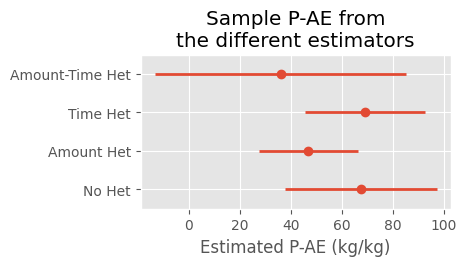

In [39]:
tmp_df = maize_std*ate_df/100 # Convert to N-AE

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.errorbar(
    y=tmp_df.index,
    x=tmp_df['Mean'],
    xerr=np.abs(tmp_df[['LowerCI', 'UpperCI']].values.T - tmp_df['Mean'].values),
    fmt='o', linewidth=2, label='ATE'
)
ax.set_xlabel('Estimated P-AE (kg/kg)')
ax.set_ylim(-0.5, 3.5)
ax.set_title('Sample P-AE from\nthe different estimators')
# plt.tight_layout()
# ax.axvline(cf_estimator.ate(X) * maize_std/100, color='k', linestyle='--', label='ATE')
# ax.legend()
tmp_df

In [40]:
timing_pretty_names = {
    'timing_100Basal': '100% Basal',
    'timing_50Basal-50Emergence': '50% Basal, 50% Emergence',
    'timing_50Basal-50V56': '50% Basal, 50% V5-6',
    'other': 'Other'
}

In [41]:
x_names_cate

['other',
 'timing_100Basal',
 'timing_50Basal-50Emergence',
 'timing_50Basal-50V56']

In [42]:
lineardml_time_estimate.summary(feature_names=x_names_cate)

CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
other,0.634,0.668,0.949,0.343,-0.676,1.943
timing_100Basal,4.449,0.832,5.35,0.0,2.819,6.078
timing_50Basal-50Emergence,1.064,0.88,1.208,0.227,-0.662,2.789
timing_50Basal-50V56,2.187,0.861,2.539,0.011,0.499,3.876


CATE Intercept Results:  No intercept was fitted!


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Other,11.327482,11.934949,16.955490,6.128275,-12.077883,34.714980
100% Basal,79.488907,14.865087,95.586796,0.000000,50.366201,108.593746
"50% Basal, 50% Emergence",19.010159,15.722688,21.582962,4.055739,-11.827749,49.830201
"50% Basal, 50% V5-6",39.074453,15.383221,45.363528,0.196534,8.915479,69.251293


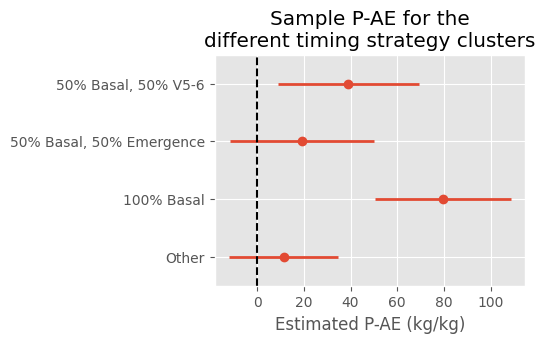

In [43]:
timing_coefs = pd.read_html(
    lineardml_time_estimate.summary(feature_names=x_names_cate).tables[0].as_html()
    , header=0, index_col=0
)[0]

tmp_df = timing_coefs*maize_std/100 # Convert to N-AE
tmp_df.index = [timing_pretty_names[i] for i in tmp_df.index]

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.errorbar(
    y=tmp_df.index,
    x=tmp_df['point_estimate'],
    xerr=np.abs(tmp_df[['ci_lower', 'ci_upper']].values.T - tmp_df['point_estimate'].values),
    fmt='o', linewidth=2, label='ATE'
)
ax.set_xlabel('Estimated P-AE (kg/kg)')
ax.set_ylim(-0.5, 3.5)
ax.set_title('Sample P-AE for the\ndifferent timing strategy clusters')
ax.axvline(0, color='k', linestyle='--', label='ATE')
# ax.legend()
tmp_df

In [44]:
t_grid = np.linspace(np.percentile(T, 1), np.percentile(T, 99), 100)

def plot_response_curve(est, ax, X=None, ci=True, kwargs_line={}, kwargs_ci={}):
    lift_inference = []

    for t in t_grid:
        if ci:
            ate_inf = est.ate_inference(X=X, T0=0, T1=t)
            lift_inference.append((ate_inf.mean_point, *ate_inf.conf_int_mean()))
        else:
            lift_inference.append([est.ate(X=X, T0=0, T1=t)])
    lift_inference = np.array(lift_inference)
    err = np.abs(lift_inference[:, 1:] - lift_inference[:, 0].reshape(-1, 1)).T * maize_std
    sns.lineplot(
        x=t_grid*100, y=lift_inference[:, 0]*maize_std, ax=ax,
        **kwargs_line
    )
    if ci:
        if not kwargs_ci:
            kwargs_ci=dict(alpha=.1)
        ax.fill_between(
            x=t_grid*100, y1=lift_inference[:,1]* maize_std, 
            y2=lift_inference[:,2]* maize_std, **kwargs_ci
        )
    ax.set_xlabel('Total P Fertilizer applied (kg/ha)')
    ax.set_ylabel('Yield (kg/ha)')

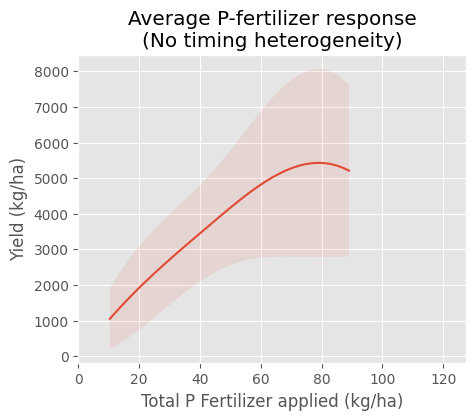

In [45]:
fig, ax =plt.subplots(1, 1, figsize=(5, 4))
plot_response_curve(lineardml_amount_estimate, ax)
ax.set_title('Average P-fertilizer response\n(No timing heterogeneity)')
ax.set_xlim(0, 100*T.max())

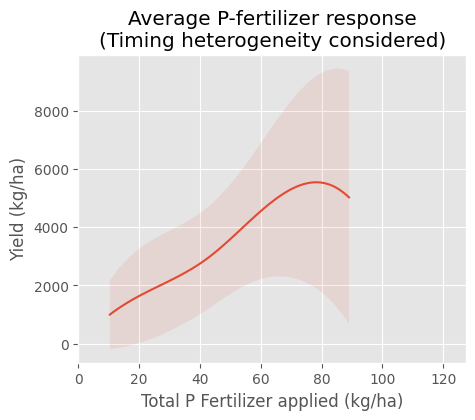

In [46]:
fig, ax =plt.subplots(1, 1, figsize=(5, 4))
plot_response_curve(lineardml_timeamount_estimate, ax, X)
ax.set_title('Average P-fertilizer response\n(Timing heterogeneity considered)')
ax.set_xlim(0, 100*T.max())

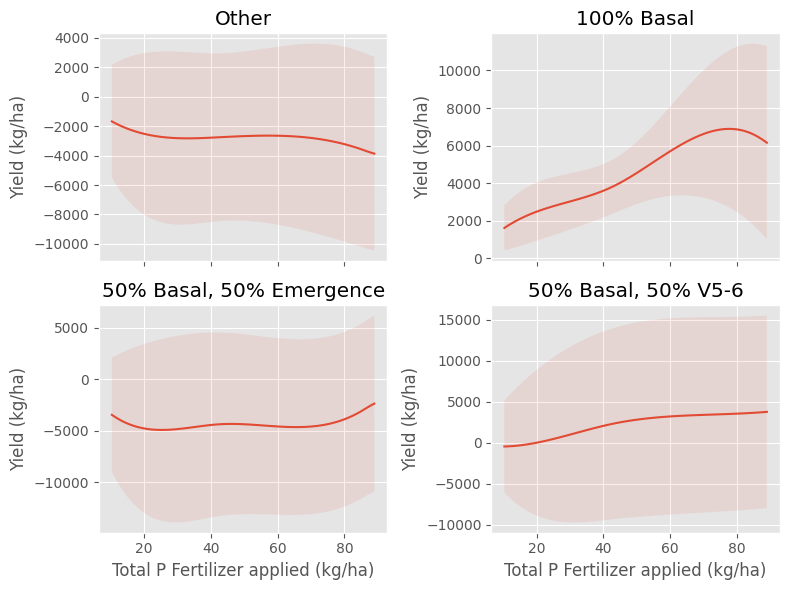

In [47]:
fig, axes =plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=False)
axes = axes.flatten()

for n, x_name in enumerate(x_names_cate):
    ax = axes[n]
    X_ = np.zeros(shape=(1, len(x_names_cate)))
    X_[0, n] = 1
    plot_response_curve(lineardml_timeamount_estimate, ax, X_)
    ax.set_title(timing_pretty_names[x_name])
plt.tight_layout()

# Benchmark models

In [48]:
from statsmodels.api import OLS

In [49]:
# OLS model for homogeneous effect
ols_model_hom = OLS(
    endog=transformed_data_pstrimmed[outcome_name],
    exog=transformed_data_pstrimmed[[treatment_name] + features],
).fit().summary()
pd.read_html(
    ols_model_hom.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[[treatment_name]]

,coef,std err,t,P>|t|,[0.025,0.975]
fertP_total,1.3945,0.349,3.999,0.0,0.71,2.079


In [50]:
# OLS model for variable timing
endog = transformed_data_pstrimmed[outcome_name]
exog = transformed_data_pstrimmed[w_names]
exog = pd.concat([
    exog,
    pd.DataFrame(
        np.multiply(transformed_data_pstrimmed[[treatment_name]].to_numpy(), X),
        index=exog.index, columns=x_names_cate
    )
], axis=1)
ols_model_time = OLS(
    endog=endog,
    exog=exog,
).fit().summary()
pd.read_html(
    ols_model_time.tables[1].as_html()
    , header=0, index_col=0
)[0].loc[x_names_cate] 

,coef,std err,t,P>|t|,[0.025,0.975]
other,0.6093,0.645,0.944,0.345,-0.658,1.876
timing_100Basal,2.2478,0.480,4.678,0.000,1.304,3.191
timing_50Basal-50Emergence,0.5712,0.967,0.590,0.555,-1.329,2.471
timing_50Basal-50V56,1.1660,0.405,2.882,0.004,0.372,1.960


In [51]:
from sklearn.base import clone
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
# A RF with PDP to simulate the effect of fertilizer on yield
# This article was just released and it uses PDP: https://www.sciencedirect.com/science/article/pii/S1161030125004216
X_rf_response = np.hstack([W, X, T.reshape(-1, 1)])
model_rf_response = clone(model_q)
y_cv_pred = cross_val_predict(
    model_rf_response,
    X_rf_response,
    Y
)
model_rf_response = model_rf_response.fit(X_rf_response, Y)
r2_score(Y, y_cv_pred)

In [52]:
rf_response_pdp = partial_dependence(
    model_rf_response, X_rf_response, features=[X_rf_response.shape[1]-1],
    kind='individual'
)

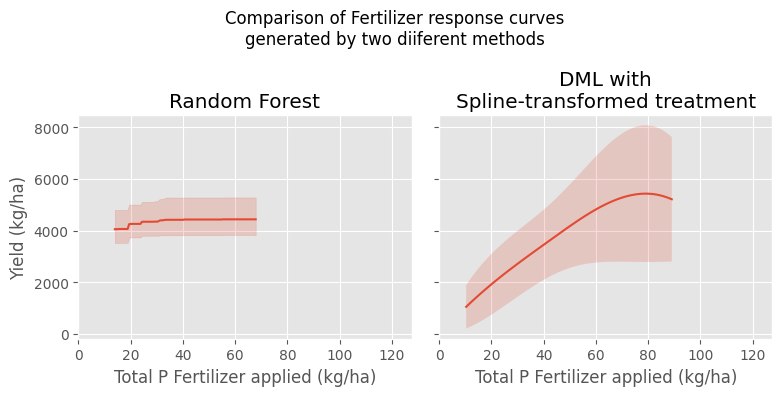

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax = axes[0]
sns.lineplot(
    x=np.repeat(rf_response_pdp['grid_values'][0], len(Y))*100,
    y=rf_response_pdp['individual'][0].T.flatten()*(maize_std) + maize_mean,
    errorbar='pi', ax=ax
)
ax.set_xlabel('Total P Fertilizer applied (kg/ha)')
ax.set_ylabel('Yield (kg/ha)')
ax.set_title('Random Forest')

ax = axes[1]
plot_response_curve(lineardml_amount_estimate, ax, kwargs_ci=dict(alpha=.2))
ax.set_title('DML with\nSpline-transformed treatment')
ax.set_xlim(0, 100*T.max())

fig.suptitle('Comparison of Fertilizer response curves\ngenerated by two diiferent methods')
plt.tight_layout()

# Sensitivity analysis

In [54]:
lineardml_hom_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
    0.45       1.195 1.642       2.089    2.807
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.172                 0.096
----------------------------------------------
"""

In [55]:
lineardml_time_estimate.sensitivity_summary()

<class 'econml.utilities.Summary'>
"""
Sensitivity Analysis Summary for c_y=0.05, c_t=0.05, rho=1.0
===============================================
CI Lower Theta Lower Theta Theta Upper CI Upper
-----------------------------------------------
   0.559       1.261 1.683       2.105    2.786
   Robustness Values for null_hypothesis=0    
==============================================
Robustness Value (Theta) Robustness Value (CI)
----------------------------------------------
                   0.185                  0.11
----------------------------------------------
"""

## Placebo test

In [56]:
from tqdm import tqdm

In [57]:
# Run placebo for the Timing and Amount heterogeneous estimators
placebo_estimates_amount = []

for _ in tqdm(range(100)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by amount
    lineardml_amount_placebo = LinearDML(
        model_y=model_q, 
        model_t=MultiOutputRegressor(model_treatment), 
        treatment_featurizer=SplineTransformer(n_knots=4, degree=3),
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED
    )
    lineardml_amount_placebo = lineardml_amount_placebo.fit(
        Y=Y, T=T_placebo.reshape(-1, 1), W=W,
        inference=None, cache_values=True,
        sample_weight=sample_weights
    )
    placebo_estimates_amount.append(lineardml_amount_placebo)

100%|██████████| 100/100 [02:40<00:00,  1.60s/it]


In [58]:
placebo_estimates_time = []

for _ in tqdm(range(100)):
    T_placebo = np.random.choice(T, size=len(T), replace=True)
    # Heterogeneous by amount
    lineardml_time_placebo = LinearDML(
        model_y=model_q, 
        model_t=model_treatment, 
        discrete_treatment=False,
        cv=5,
        random_state=RANDOM_SEED,
        fit_cate_intercept=False
    )
    lineardml_time_placebo = lineardml_time_placebo.fit(
        Y=Y, T=T_placebo, W=W, X=X,
        inference='statsmodels', cache_values=True,
        sample_weight=sample_weights
    )
    placebo_estimates_time.append(lineardml_time_placebo)

100%|██████████| 100/100 [01:45<00:00,  1.06s/it]


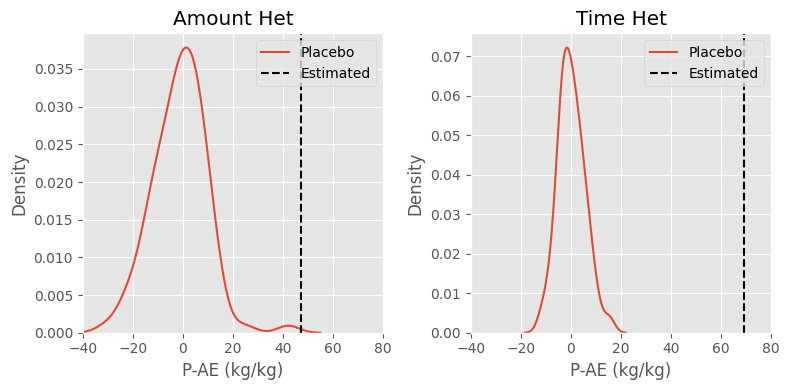

In [62]:
ate_placebo = {
    'Amount Het': np.array([i.ate() for i in placebo_estimates_amount]),
    'Time Het': np.array([i.ate(X) for i in placebo_estimates_time])
}

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for n, (est_name, placebo_estimates) in enumerate(ate_placebo.items()):
    ax = axes[n]
    sns.kdeplot((maize_std/100)*np.array(placebo_estimates).flatten(), label='Placebo', ax=ax)
    ax.set_xlabel('P-AE (kg/kg)')
    ax.set_title(est_name)
    ax.axvline(
        (maize_std/100)*estimates_dict[est_name].ate(X=X if 'Time' in est_name else None), 
        label='Estimated', color='k', linestyle='--'
    )
    ax.legend()
    ax.set_xlim(-40, 80)
plt.tight_layout()

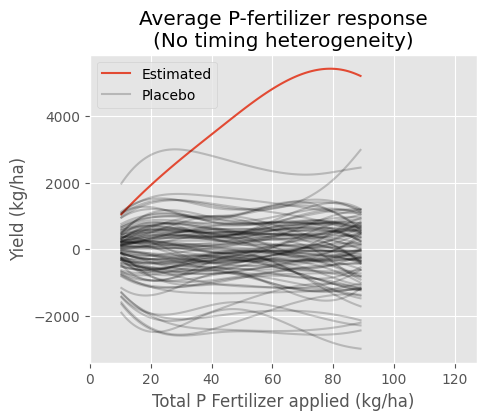

In [63]:
fig, ax =plt.subplots(1, 1, figsize=(5, 4))
plot_response_curve(
    lineardml_amount_estimate, ax, ci=False, kwargs_line=dict(label='Estimated')
)
for est in placebo_estimates_amount:
    plot_response_curve(est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2))
plot_response_curve(
    est, ax, ci=False, kwargs_line=dict(color='k', alpha=.2, label='Placebo')
)

ax.set_title('Average P-fertilizer response\n(No timing heterogeneity)')
ax.set_xlim(0, 100*T.max())
ax.legend()


In [64]:
placebo_time_coefs = []
for est in placebo_estimates_time:
    placebo_time_coefs.append(pd.read_html(
        est.summary(feature_names=x_names_cate).tables[0].as_html()
        , header=0, index_col=0
    )[0])

CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!
CATE Intercept Results:  No intercept was fitted!


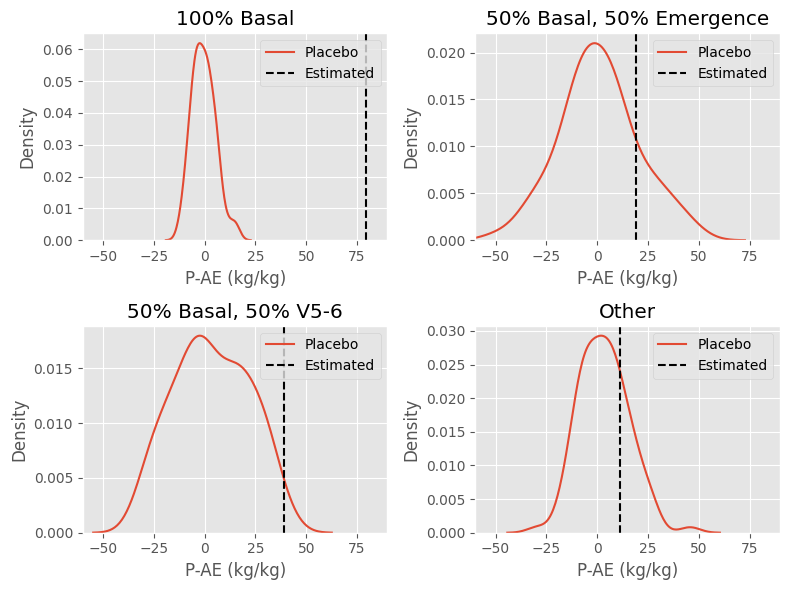

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
for n, name in enumerate(timing_pretty_names):
    ax = axes[n]
    x = [i.loc[name, 'point_estimate'] for i in placebo_time_coefs]
    sns.kdeplot((maize_std/100)*np.array(x), label='Placebo', ax=ax)
    ax.set_xlabel('P-AE (kg/kg)')
    ax.set_title(timing_pretty_names[name])
    ax.axvline(
        (maize_std/100)*timing_coefs.loc[name, 'point_estimate'], 
        label='Estimated', color='k', linestyle='--'
    )
    ax.legend()
    ax.set_xlim(-60, 90)
plt.tight_layout()